In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Reading the necessary csv files and then fill na's

In [4]:
food_nutrient=pd.read_csv('food_nutrient.csv')
food_nutrient.head(5)

C:\Users\pelin\AppData\Local\Temp\ipykernel_19676\3419431068.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  food_nutrient=pd.read_csv('food_nutrient.csv')


,id,fdc_id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired
0,13338591,323505,2048,35.0,NaN,49.0,NaN,NaN,NaN,NaN,NaN
1,13338389,326196,2048,36.0,NaN,49.0,NaN,NaN,NaN,NaN,NaN
2,13338390,747447,2048,32.0,NaN,49.0,NaN,NaN,NaN,NaN,NaN
3,13338391,321611,2048,20.0,NaN,49.0,NaN,NaN,NaN,NaN,NaN
4,13338392,746769,2048,17.0,NaN,49.0,NaN,NaN,NaN,NaN,NaN


In [6]:
food_attribute=pd.read_csv('food_attribute.csv')
food_attribute.head(3)

C:\Users\pelin\AppData\Local\Temp\ipykernel_19676\1065878398.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  food_attribute=pd.read_csv('food_attribute.csv')


,id,fdc_id,seq_num,food_attribute_type_id,name,value
0,2574,170797,0.0,1000,NaN,"Beef, Chuck, Bnls Country Style Beef Ribs, URM..."
1,2575,170798,0.0,1000,NaN,"Beef, Chuck, Bnls Country Style Beef Ribs, URM..."
2,2576,170799,0.0,1000,NaN,"Beef, Chuck, Bnls, Country Style Beef Ribs, UR..."


In [8]:
food_category=pd.read_csv('food_category.csv')
food_category.head(3)

,id,code,description
0,1,100,Dairy and Egg Products
1,2,200,Spices and Herbs
2,3,300,Baby Foods


In [10]:
nutrient=pd.read_csv('nutrient.csv')
nutrient.head(3)

,id,name,unit_name,nutrient_nbr,rank
0,1002,Nitrogen,G,202.0,500.0
1,1003,Protein,G,203.0,600.0
2,1004,Total lipid (fat),G,204.0,800.0


In [12]:
food=pd.read_csv('food.csv')
food.head(3)

,fdc_id,data_type,description,food_category_id,publication_date
0,1105898,experimental_food,Metabolizable Energy of Almonds,NaN,2020-10-30
1,1105899,experimental_food,"Metabolizable Energy of Almonds, Food Processi...",NaN,2020-10-30
2,1105900,experimental_food,Metabolizable Energy of Cashews,NaN,2020-10-30


In [14]:
food_nutrient.fillna(0,inplace=True)

In [16]:
food_nutrient.describe()

,id,fdc_id,nutrient_id,amount,data_points,derivation_id,min,max,median,min_year_acquired
count,7.547844e+06,7.547844e+06,7.547844e+06,7.547844e+06,7.547844e+06,7.547844e+06,7.547844e+06,7.547844e+06,7.547844e+06,7.547844e+06
mean,6.785234e+06,6.222207e+05,1.174968e+03,1.366018e+03,2.408187e-01,6.215880e+01,3.470461e-01,5.641883e-01,6.373881e-02,6.415850e+00
std,3.499681e+06,2.665601e+05,2.340335e+02,2.739979e+06,5.290306e+00,2.383436e+01,3.070572e+01,5.912722e+01,2.207324e+01,1.135099e+02
min,1.283674e+06,1.675120e+05,1.002000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.050081e+06,4.302300e+05,1.008000e+03,0.000000e+00,0.000000e+00,7.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,5.937042e+06,5.705160e+05,1.093000e+03,3.330000e+00,0.000000e+00,7.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.002804e+07,8.214900e+05,1.253000e+03,3.333000e+01,0.000000e+00,7.500000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,1.333859e+07,1.105897e+06,2.048000e+03,7.500000e+09,2.526000e+03,7.900000e+01,3.720000e+04,5.600000e+04,3.850000e+04,2.020000e+03


In [20]:
food.fillna(1,inplace=True)

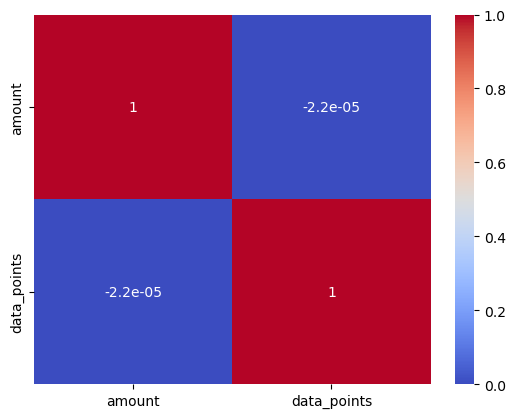

In [38]:
columns = food_nutrient[['amount', 'data_points']]

correlation_matrix = columns.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.show()

In [ ]:
Regression between amount&data points

Slope: -4.218791407768356e-11, Intercept: 0.24081876029472582, R-value: -2.1850156644430946e-05


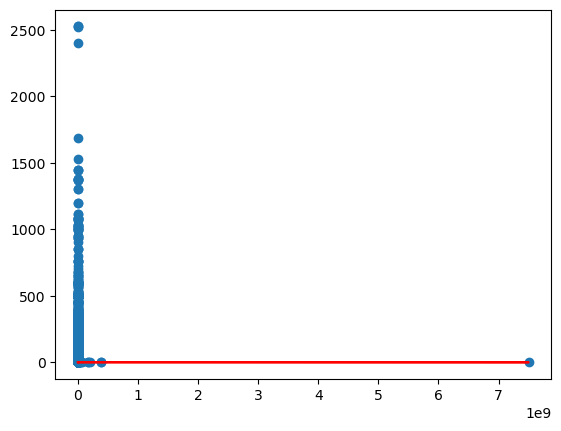

In [14]:

x = food_nutrient['amount']
y = food_nutrient['data_points']

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
print(f"Slope: {slope}, Intercept: {intercept}, R-value: {r_value}")


plt.scatter(x, y)
plt.plot(x, slope * x + intercept, color='red')
plt.show()


Histogram of rank

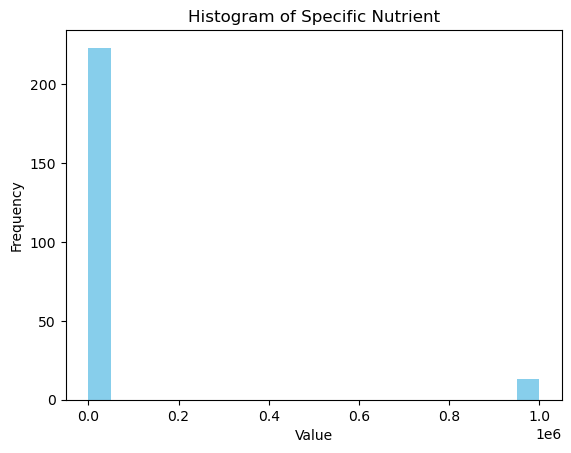

In [40]:
plt.hist(nutrient['rank'], bins=20, color='skyblue')
plt.title('Histogram of Specific Nutrient')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()


Top foods that contain the most protein

In [47]:
protein_id = nutrient[nutrient['name'] == 'Protein']['id'].values[0]


protein_data = food_nutrient[food_nutrient['nutrient_id'] == protein_id]


top_protein_foods = protein_data.sort_values(by='amount', ascending=False).head(5)


print(top_protein_foods)

               id   fdc_id  nutrient_id   amount  data_points  derivation_id  \
5656514  10018902   820442         1003  1040.00          0.0           70.0   
5656522  10018918   820444         1003  1040.00          0.0           70.0   
5656489  10018852   820436         1003  1040.00          0.0           70.0   
6685412  12076697  1035011         1003   888.89          0.0           70.0   
6137493  10980860   920394         1003   888.89          0.0           70.0   

         min  max  median footnote  min_year_acquired  
5656514  0.0  0.0     0.0        0                0.0  
5656522  0.0  0.0     0.0        0                0.0  
5656489  0.0  0.0     0.0        0                0.0  
6685412  0.0  0.0     0.0        0                0.0  
6137493  0.0  0.0     0.0        0                0.0  


C:\Users\pelin\AppData\Local\Temp\ipykernel_24644\3485334552.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='amount', y='fdc_id', data=top_protein_foods, palette='coolwarm')


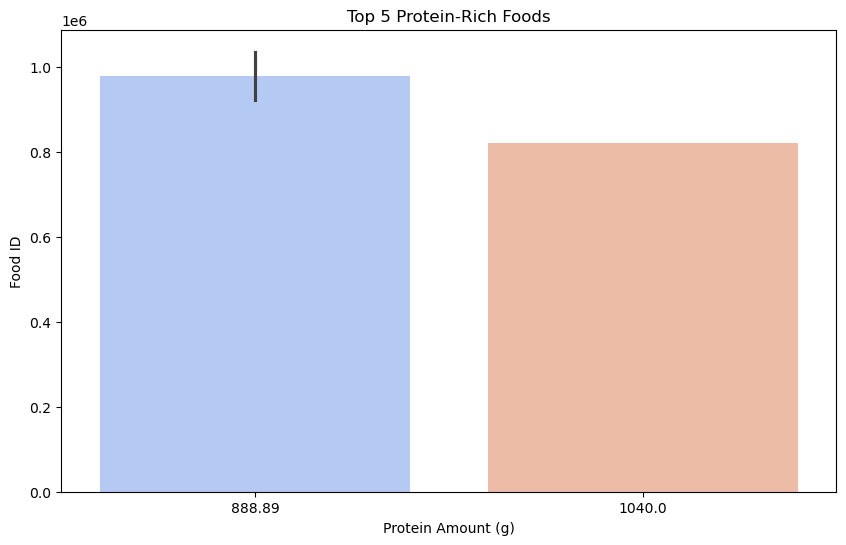

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(x='amount', y='fdc_id', data=top_protein_foods, palette='coolwarm')
plt.title('Top 5 Protein-Rich Foods')
plt.xlabel('Protein Amount (g)')
plt.ylabel('Food ID')
plt.show()

Average Vitamin Distribution by Category

In [50]:
vitamin_ids = nutrient[nutrient['name'].str.contains('Vitamin')]['id']


vitamin_data = food_nutrient[food_nutrient['nutrient_id'].isin(vitamin_ids)]


vitamin_mean_by_category = vitamin_data.groupby('fdc_id')['amount'].mean()


print(vitamin_mean_by_category)

fdc_id
167513       0.366667
167515       0.000000
167516     177.655200
167517     161.400833
167518     236.846875
              ...    
1105843      0.044000
1105858      0.027000
1105872      0.030000
1105887      0.042000
1105897      0.036000
Name: amount, Length: 361952, dtype: float64


Correlation between energy and fat amount

In [53]:
energy_id = nutrient[nutrient['name'].str.contains('Energy')]['id'].values[0]
fat_id = nutrient[nutrient['name'] == 'Total lipid (fat)']['id'].values[0]

energy_data = food_nutrient[food_nutrient['nutrient_id'] == energy_id][['id', 'amount']]
energy_data.rename(columns={'amount': 'energy'}, inplace=True)

fat_data = food_nutrient[food_nutrient['nutrient_id'] == fat_id][['id', 'amount']]
fat_data.rename(columns={'amount': 'fat'}, inplace=True)

In [55]:
merged_data = pd.merge(energy_data, fat_data, on='id', how='inner')


correlation = merged_data['energy'].corr(merged_data['fat'])
print(f"Correlation (Energy - Fat): {correlation}")


Correlation (Energy - Fat): nan


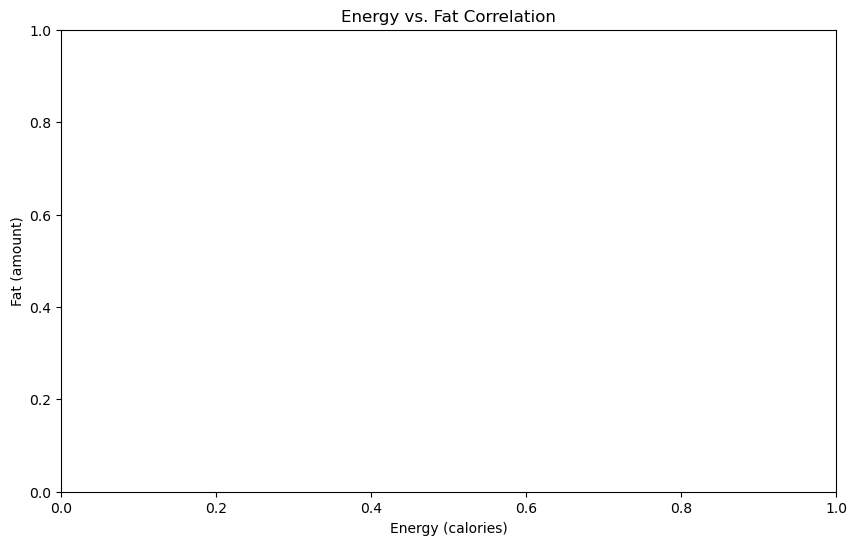

In [59]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_data, x='energy', y='fat', color='green', alpha=0.6)
plt.title('Energy vs. Fat Correlation')
plt.xlabel('Energy (calories)')
plt.ylabel('Fat (amount)')
plt.show()

Average food contents by category

In [60]:
carb_id = nutrient[nutrient['name'].str.contains('Carbohydrate')]['id'].values[0]
fat_id = nutrient[nutrient['name'].str.contains('Total lipid')]['id'].values[0]
protein_id = nutrient[nutrient['name'].str.contains('Protein')]['id'].values[0]

In [62]:
filtered_data = food_nutrient[food_nutrient['nutrient_id'].isin([carb_id, fat_id, protein_id])]
filtered_data = filtered_data.merge(
    nutrient[['id', 'name']],
    left_on='nutrient_id',
    right_on='id',
    how='left'
)
filtered_data.rename(columns={'name': 'nutrient'}, inplace=True)

In [66]:
category_averages = filtered_data.groupby(['fdc_id', 'nutrient'])['amount'].mean().reset_index()
print(category_averages)

          fdc_id                     nutrient  amount
0         167512  Carbohydrate, by difference   41.18
1         167512                      Protein    5.88
2         167512            Total lipid (fat)   13.24
3         167513  Carbohydrate, by difference   53.42
4         167513                      Protein    4.34
...          ...                          ...     ...
1465537  1105878            Total lipid (fat)    0.20
1465538  1105893            Total lipid (fat)    0.20
1465539  1105897  Carbohydrate, by difference   15.70
1465540  1105897                      Protein    0.15
1465541  1105897            Total lipid (fat)    0.16

[1465542 rows x 3 columns]


## Insights and Potential Findings from the Data

The dataset represents food items and their respective macronutrient values (carbohydrates, protein, fat) for each product. Each row indicates the nutrient composition of a specific product (`fdc_id`). Below are possible insights and analyses that can be derived from this data
---

### Key Findings and Opportunities

1. **Nutritional Breakdown of Products**  
   - Each product's macronutrient distribution can be analyzed. For instance:
     - `fdc_id = 167512`:  
       - Carbohydrates: 41.18%  
       - Protein: 5.88%  
       - Fat: 13.24%  
     - This distribution suggests a carbohydrate-dominant food item.

2. **Identifying High Nutrient Items**  
   - Find the products with the highest carbohydrate, protein, or fat contents. This information is valuable for dietary planning or specific product recommendations.

3. **Average Macronutrient Content**  
   - Calculate the average values for each nutrient across all products to underde4 across these categories.

5. **Food Variety Analysis**  
   - The dataset includes three main nutrients (`Carbohydrate, by difference`, `Protein`, `Total lipid (fat)`), allowing analysis of food products' dtein or low in carbohydrates.

---

### Additional Questions to Explore

1. **Energy (Calories):**  
   - If the dataset included calorie values, a correlation analysis between macronutrients (particularly fat) and calorie content could provide meaningful insights.

2. **Category Mappings for `fdc_id`:**  
   - Understanding which `fdc_id` corresponds to what food items would enable deeper exploration and specific item recommendations.

3. **Diet-Specific Product Analysis:**  
   - Identify foods suitable for certain dietary preferences, sthe mean value of each nutrient across all products.

---

This dataset provides valuable insights for dietary analysis, nutritional recommendations, and product comparisons. Further exploration or additional data points, such as calorie content, could enhance these findings.
